In [233]:
import numpy as np
import os
import seaborn
import matplotlib.pyplot as plt
import pandas as pd

In [234]:
file_path_lko = "/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko"
file_path_wt = "/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/wt"

In [235]:
condition = "all_voxels"
folder_cond = "non_normalize_radius"

In [236]:
pkl_lko = []
pkl_wt = []
for file_lko in os.listdir(file_path_lko):
    pkl_lko.append(os.path.join(file_path_lko, file_lko))
for file_wt in os.listdir(file_path_wt):
    pkl_wt.append(os.path.join(file_path_wt, file_wt))

In [237]:
pkl_lko, pkl_wt

(['/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko/structural_full_k_Mesh_5_nonzero_voxels.pkl',
  '/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko/structural_full_k_Mesh_3_nonzero_voxels.pkl',
  '/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko/structural_full_k_Mesh_2_nonzero_voxels.pkl',
  '/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko/structural_full_k_Mesh_1_nonzero_voxels.pkl',
  '/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/lko/structural_full_k_Mesh_6_nonzero_voxels.pkl'],
 ['/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/wt/structural_full_w_Mesh_2_nonzero_voxels.pkl',
  '/home/desktop/Desktop/22104412_Docs/SurfaceRecon/Vein-recons/pkl_voxel_analysis/results_density/wt/stru

In [238]:
import pickle

def fractional_anisotropy(eigvals):

    l1, l2, l3 = eigvals

    if np.sum(eigvals) == 0:
        return 0

    lm = np.mean(eigvals)

    num = (
        (l1-lm)**2 +
        (l2-lm)**2 +
        (l3-lm)**2
    )

    den = l1**2 + l2**2 + l3**2

    return np.sqrt(1.5 * num / (den + 1e-8))

radius_lko = []
radius_wt = []

tort_lko = []
tort_wt = []

wt_rows = []
lko_rows =[]

for animal_id, wt_data in enumerate(pkl_wt):
    with open(wt_data, "rb") as f:
        data = pickle.load(f)

    for v in data:
        wt_rows.append({
            "animal_id": animal_id,
            # density + radius
            "density": v["density"],
            "mean_radius": v["mean_radius"],
            "min_radius": v["min_radius"],
            "max_radius": v["max_radius"],
            # "normalized_radius": v["norm_radius"],

            # tortuosity
            "mean_tortuosity": v["mean_tortuosity"],
            "min_tortuosity": v["min_tortuosity"],
            "max_tortuosity": v["max_tortuosity"],

            # # shape (VERY important for structure)
            "eigenvals_0": v["eigenvals"][0],
            "eigenvals_1": v["eigenvals"][1],
            "eigenvals_2": v["eigenvals"][2],
            "linearity": v["linearity"],
            "planarity": v["planarity"],
            "sphericity": v["sphericity"],

            # # distributions
            "radius": v["radius_data"],
            "tortuosity": v["tortuosity_data"],

            "structure_score" :0.4 * v["linearity"] +
                0.3 * v["planarity"] +
                0.3 * v["sphericity"],
            "FA": fractional_anisotropy(v["eigenvals"])
            # "FD": v["FD_tot"],
            # "OE": v["orientation_entropy"],
            # "lac_vals": v["lac_vals"],
            # "mean_lac": v["mean_lac"]
        })


for animal_id, lko_data in enumerate(pkl_lko):
    with open(lko_data, "rb") as f:
        data = pickle.load(f)

    for v in data:
        lko_rows.append({
            "animal_id": animal_id,
            # density + radius
            "density": v["density"],
            "mean_radius": v["mean_radius"],
            "min_radius": v["min_radius"],
            "max_radius": v["max_radius"],
            # "normalized_radius": v["norm_radius"],

            # tortuosity
            "mean_tortuosity": v["mean_tortuosity"],
            "min_tortuosity": v["min_tortuosity"],
            "max_tortuosity": v["max_tortuosity"],

            # # shape (VERY important for structure)
            "eigenvals_0": v["eigenvals"][0],
            "eigenvals_1": v["eigenvals"][1],
            "eigenvals_2": v["eigenvals"][2],
            "linearity": v["linearity"],
            "planarity": v["planarity"],
            "sphericity": v["sphericity"],

            # # distributions
            "radius": v["radius_data"],
            "tortuosity": v["tortuosity_data"],

            "structure_score" :0.4 * v["linearity"] +
                0.3 * v["planarity"] +
                0.3 * v["sphericity"],
            
            "FA": fractional_anisotropy(v["eigenvals"])
            # "FD": v["FD_tot"],
            # "OE": v["orientation_entropy"],
            # "lac_vals": v["lac_vals"],
            # "mean_lac": v["mean_lac"]
        })


df_wt = pd.DataFrame(wt_rows)
df_lko = pd.DataFrame(lko_rows)

def clean_df(df):
    df["tortuosity"] = df["tortuosity"].apply(
        lambda x: x if isinstance(x, (list, np.ndarray)) else np.nan
    )
    df = df.dropna(subset=["tortuosity"]).reset_index(drop=True)
    return df

df_wt = clean_df(df_wt)
df_lko = clean_df(df_lko)

radius_wt = np.concatenate(df_wt["radius"].values)
tort_wt   = np.concatenate(df_wt["tortuosity"].values)

radius_lko = np.concatenate(df_lko["radius"].values)
tort_lko   = np.concatenate(df_lko["tortuosity"].values)

density_wt = df_wt['density']
density_lko = df_lko['density']

strut_s_wt = df_wt['structure_score']
strut_s_lko = df_lko['structure_score']

# FA_wt = df_wt["FA"]
# FA_lko = df_lko["FA"]

In [239]:
def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

In [240]:
lko_radius = np.array(radius_lko)
wt_radius = np.array(radius_wt)

# lko_norm = normalize(lko_radius)
# wt_norm = normalize(wt_radius)

lko_norm = lko_radius
wt_norm = wt_radius

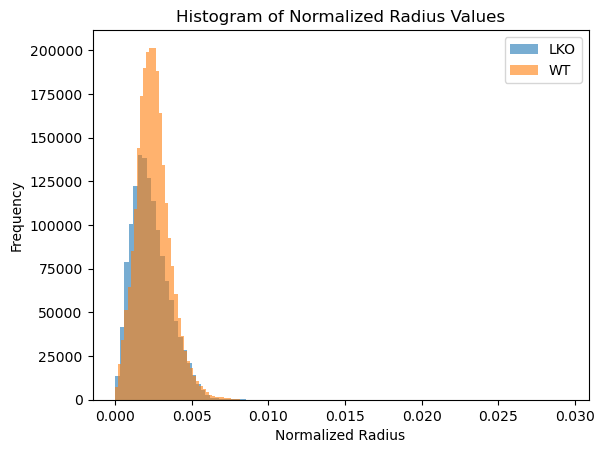

In [241]:
plt.figure()

plt.hist(lko_norm, bins=100, alpha=0.6, label="LKO")
plt.hist(wt_norm, bins=100, alpha=0.6, label="WT")

plt.xlabel("Normalized Radius")
plt.ylabel("Frequency")
plt.title("Histogram of Normalized Radius Values")
plt.legend()

plt.show()

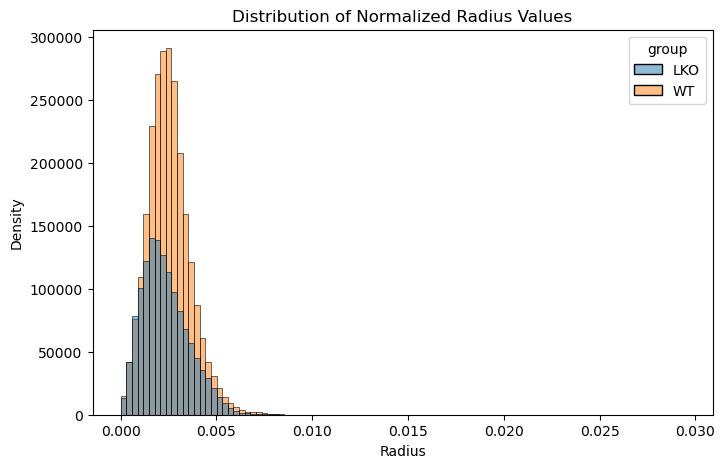

In [242]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a combined dataframe
df = pd.DataFrame({
    "Normalized Radius": np.concatenate([lko_norm, wt_norm]),
    "group": ["LKO"] * len(lko_norm) + ["WT"] * len(wt_norm)
})

# Plot
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Normalized Radius",
    hue="group",
    bins=100,
    stat="count",   # better than raw counts
    common_norm=False,
    alpha=0.5
)

plt.title("Distribution of Normalized Radius Values")
plt.xlabel("Radius")
plt.ylabel("Density")
plt.show()

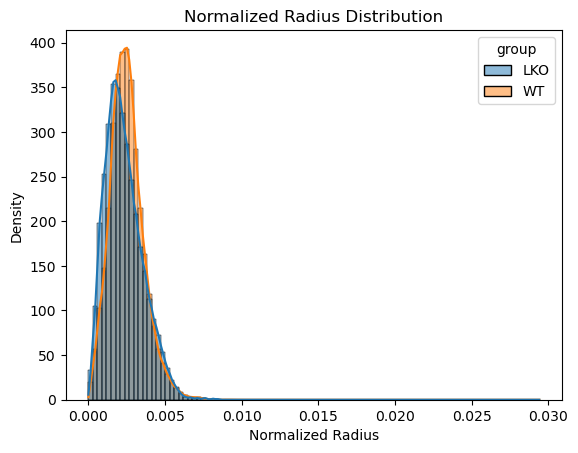

In [258]:
plt.figure()
sns.histplot(data=df, x="Normalized Radius", hue="group", bins=100, kde=True, stat="density", common_norm=False)
plt.title("Normalized Radius Distribution")
plt.show()

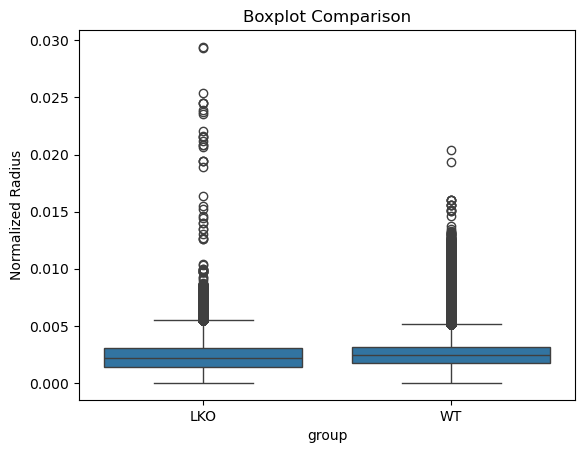

In [244]:
plt.figure()
sns.boxplot(data=df, x="group", y="Normalized Radius")
plt.title("Boxplot Comparison")
plt.show()

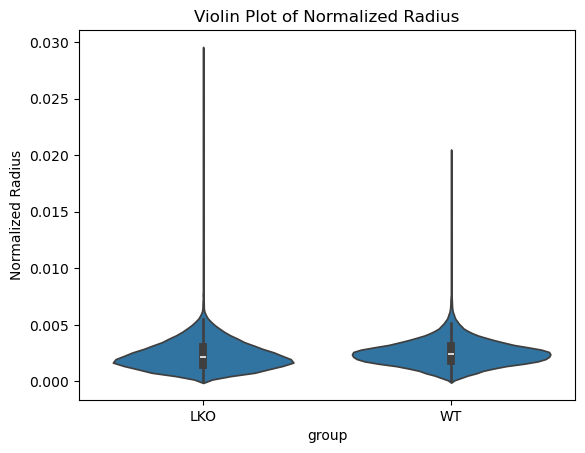

In [245]:
plt.figure()
sns.violinplot(data=df, x="group", y="Normalized Radius")
plt.title("Violin Plot of Normalized Radius")
plt.show()

In [246]:
print("LKO mean:", np.mean(lko_norm))
print("WT mean:", np.mean(wt_norm))

print("LKO std:", np.std(lko_norm))
print("WT std:", np.std(wt_norm))

LKO mean: 0.00233551076465746
WT mean: 0.0025211998061880096
LKO std: 0.0012197262365957306
WT std: 0.0011031621061626494


In [247]:
print("LKO 90th:", np.percentile(lko_norm, 90))
print("WT 90th:", np.percentile(wt_norm, 90))

LKO 90th: 0.004040045373023294
WT 90th: 0.00392729913861683


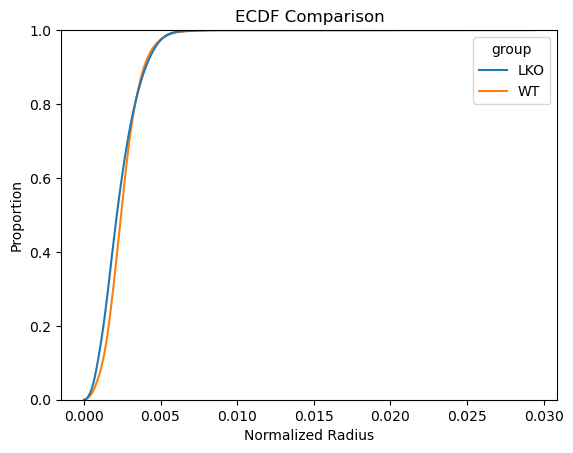

In [248]:
import seaborn as sns

sns.ecdfplot(data=df, x="Normalized Radius", hue="group")
plt.title("ECDF Comparison")
plt.show()

In [249]:
wt_animal_means = (
    df_wt.groupby("animal_id")["density"]
         .mean()
         .values
)

lko_animal_means = (
    df_lko.groupby("animal_id")["density"]
          .mean()
          .values
)

# plt.plot(wt_animal_means)
# plt.plot(lko_animal_means)

lko_animal_means

array([0.00067664, 0.00247275, 0.00131949, 0.00142714, 0.00136937])

WT: n = 5
LKO: n = 5


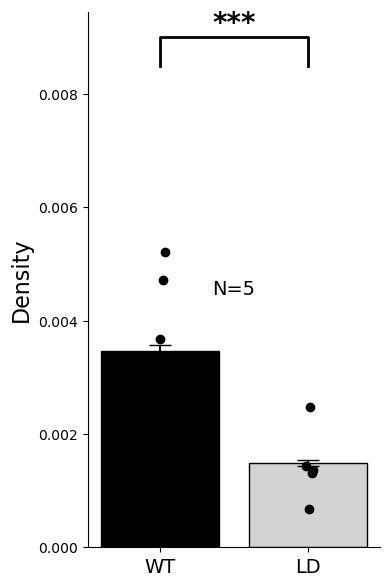

In [250]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Your arrays
WT  = density_wt
LKO = density_lko

groups = [WT, LKO]
labels = ["WT", "LD"]

x_wt = np.random.normal(0, 0.04, len(wt_animal_means))
x_lko = np.random.normal(1, 0.04, len(lko_animal_means))


# Means
means = [g.mean() for g in groups]

# SEM (use np.std(..., ddof=1) for SD)
errors = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]

fig, ax = plt.subplots(figsize=(4,6))

# Bars
bars = ax.bar(
    [0,1],
    means,
    yerr=errors,
    capsize=8,
    color=["black", "lightgray"],
    edgecolor="black"
)

# # Individual points
# for i, g in enumerate(groups):
#     x = np.random.normal(i, 0.04, size=len(g))  # jitter
#     ax.scatter(x, g, color="black", zorder=10)

ax.scatter(x_wt, wt_animal_means, color='black', zorder=10)
ax.scatter(x_lko, lko_animal_means, color='black', zorder=10)

n_wt = len(wt_animal_means)
n_lko = len(lko_animal_means)

print(f"WT: n = {n_wt}")
print(f"LKO: n = {n_lko}")

# Statistics
p = ttest_ind(WT, LKO).pvalue

# Significance text
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = "ns"

# Significance bracket
y = 0.0085   # slightly below 0.01 limit
h = 0.0005

ax.plot([0,0,1,1], [y,y+h,y+h,y], lw=2, color='black')
ax.text(0.5, y+h, stars, ha='center', va='bottom',
        fontsize=20, fontweight='bold')

# Formatting
ax.set_xticks([0,1])
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel("Density", fontsize=16)

ax.text(
    0.5, 0.5,
    f"N={n_wt}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=14
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [251]:
import numpy as np

wt = np.array(wt_animal_means)
lko = np.array(lko_animal_means)

pooled_sd = np.sqrt(
    ((len(wt)-1)*wt.var(ddof=1) +
     (len(lko)-1)*lko.var(ddof=1))
    / (len(wt)+len(lko)-2)
)

d_den = (wt.mean() - lko.mean()) / pooled_sd

print("Cohen's d =", d_den)

Cohen's d = 1.6867717623889251


In [252]:
wt_animal_means = (
    df_wt.groupby("animal_id")["structure_score"]
         .mean()
         .values
)

lko_animal_means = (
    df_lko.groupby("animal_id")["structure_score"]
          .mean()
          .values
)

# plt.plot(wt_animal_means)
# plt.plot(lko_animal_means)

lko_animal_means

array([0.38488301, 0.38043273, 0.37459072, 0.38417749, 0.38232498])

WT: n = 5
LKO: n = 5


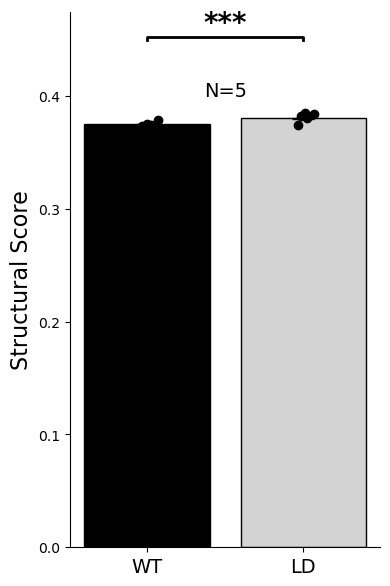

In [253]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Your arrays
WT  = strut_s_wt
LKO = strut_s_lko

groups = [WT, LKO]
labels = ["WT", "LD"]

x_wt = np.random.normal(0, 0.04, len(wt_animal_means))
x_lko = np.random.normal(1, 0.04, len(lko_animal_means))


# Means
means = [g.mean() for g in groups]

# SEM (use np.std(..., ddof=1) for SD)
errors = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]

fig, ax = plt.subplots(figsize=(4,6))

# Bars
bars = ax.bar(
    [0,1],
    means,
    yerr=errors,
    capsize=8,
    color=["black", "lightgray"],
    edgecolor="black"
)

# # Individual points
# for i, g in enumerate(groups):
#     x = np.random.normal(i, 0.04, size=len(g))  # jitter
#     ax.scatter(x, g, color="black", zorder=10)

ax.scatter(x_wt, wt_animal_means, color='black', zorder=10)
ax.scatter(x_lko, lko_animal_means, color='black', zorder=10)

n_wt = len(wt_animal_means)
n_lko = len(lko_animal_means)

print(f"WT: n = {n_wt}")
print(f"LKO: n = {n_lko}")

# Statistics
p = ttest_ind(WT, LKO).pvalue

# Significance text
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = "ns"

# Significance bracket
y = max(np.max(WT), np.max(LKO)) + 0.05
h = 0.002 

ax.plot([0,0,1,1], [y,y+h,y+h,y], lw=2, color='black')
ax.text(0.5, y+h, stars, ha='center', va='bottom',
        fontsize=20, fontweight='bold')

# Formatting
ax.set_xticks([0,1])
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel("Structural Score", fontsize=16)

ax.text(
    0.5,
    max(np.max(WT), np.max(LKO)),
    f"N={n_wt}",
    ha='center',
    fontsize=14
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [254]:
import numpy as np

wt = np.array(wt_animal_means)
lko = np.array(lko_animal_means)

pooled_sd = np.sqrt(
    ((len(wt)-1)*wt.var(ddof=1) +
     (len(lko)-1)*lko.var(ddof=1))
    / (len(wt)+len(lko)-2)
)

d_struct = (wt.mean() - lko.mean()) / pooled_sd

print("Cohen's d =", d_struct)

Cohen's d = -1.8249687058900317


In [255]:
df.to_csv(f"./{folder_cond}/{condition}/selected_voxels_distribution.csv", index=False)

In [256]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Raw data
WT = density_wt
LKO = density_lko

# t-test
t_stat, p_value = ttest_ind(WT, LKO)

# Summary statistics
wt_mean = np.mean(WT)
lko_mean = np.mean(LKO)

wt_sem = np.std(WT, ddof=1) / np.sqrt(len(WT))
lko_sem = np.std(LKO, ddof=1) / np.sqrt(len(LKO))

# Create raw-data table
raw_df = pd.DataFrame({
    "WT_density": pd.Series(WT),
    "LKO_density": pd.Series(LKO)
})

# Create summary table
summary_df = pd.DataFrame({
    "Metric": [
        "WT_mean",
        "WT_SEM",
        "WT_n",
        "LKO_mean",
        "LKO_SEM",
        "LKO_n",
        "t_statistic",
        "p_value",
        "cohen_d"
    ],
    "Value": [
        wt_mean,
        wt_sem,
        len(WT),
        lko_mean,
        lko_sem,
        len(LKO),
        t_stat,
        p_value,
        d_den
    ]
})

# Save both tables into one CSV
with open(f"./{folder_cond}/{condition}/density_results.csv", "w") as f:
    f.write("# Raw data\n")
    raw_df.to_csv(f, index=False)

    f.write("\n# Summary statistics and t-test\n")
    summary_df.to_csv(f, index=False)

print("Saved to density_results.csv")

Saved to density_results.csv


In [257]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Raw data
WT = strut_s_wt
LKO = strut_s_lko

# t-test
t_stat, p_value = ttest_ind(WT, LKO)

# Summary statistics
wt_mean = np.mean(WT)
lko_mean = np.mean(LKO)

wt_sem = np.std(WT, ddof=1) / np.sqrt(len(WT))
lko_sem = np.std(LKO, ddof=1) / np.sqrt(len(LKO))

# Create raw-data table
raw_df = pd.DataFrame({
    "WT_density": pd.Series(WT),
    "LKO_density": pd.Series(LKO)
})

# Create summary table
summary_df = pd.DataFrame({
    "Metric": [
        "WT_mean",
        "WT_SEM",
        "WT_n",
        "LKO_mean",
        "LKO_SEM",
        "LKO_n",
        "t_statistic",
        "p_value",
        "cohen_d"
    ],
    "Value": [
        wt_mean,
        wt_sem,
        len(WT),
        lko_mean,
        lko_sem,
        len(LKO),
        t_stat,
        p_value,
        d_struct
    ]
})

# Save both tables into one CSV
with open(f"./{folder_cond}/{condition}/structure_score_results.csv", "w") as f:
    f.write("# Raw data\n")
    raw_df.to_csv(f, index=False)

    f.write("\n# Summary statistics and t-test\n")
    summary_df.to_csv(f, index=False)

print("Saved to structure_score_results.csv")

Saved to structure_score_results.csv
